
[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


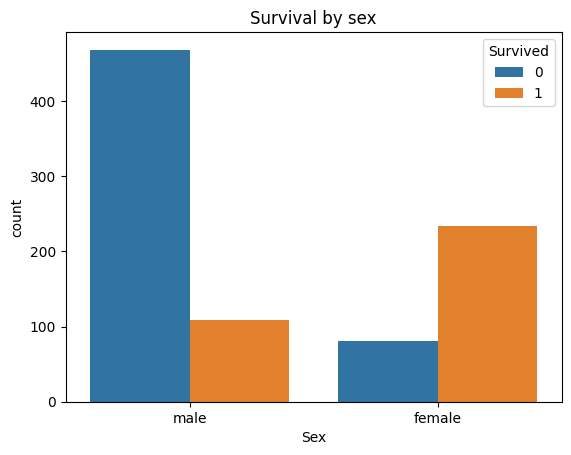

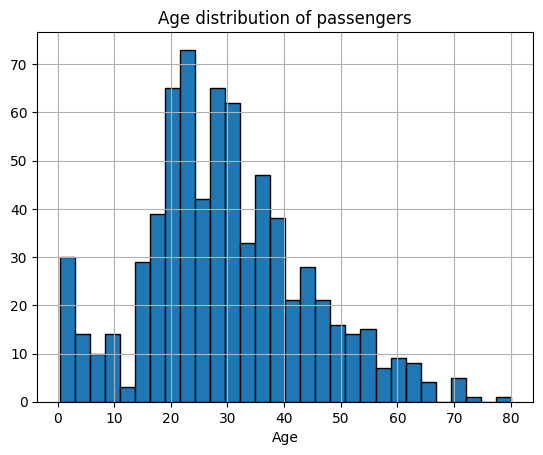

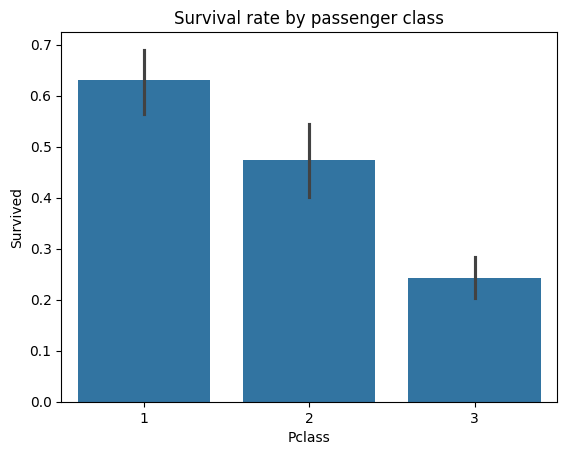

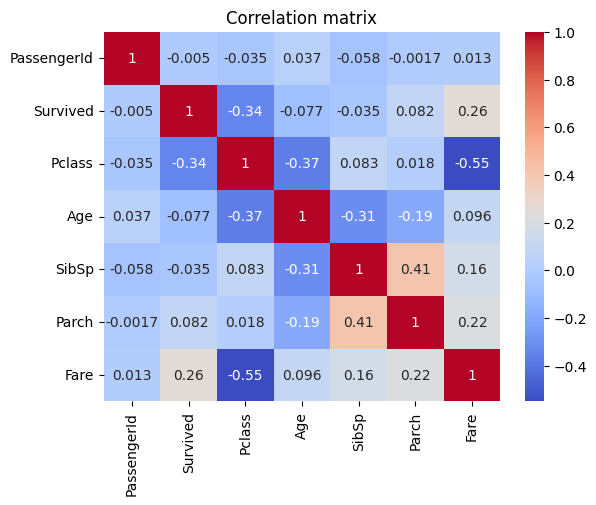

FamilySize
2     0.303538
3     0.552795
4     0.578431
5     0.724138
6     0.200000
7     0.136364
8     0.333333
9     0.000000
12    0.000000
Name: Survived, dtype: float64

In [1]:
import sys
!{sys.executable} -m pip install matplotlib seaborn
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')

df.shape        # how many rows/cols?
df.head(10)     # what does the data look like?
df.dtypes       # what types are the columns?
df.describe()   # stats: mean, std, min, max
df.isnull().sum()  # CRITICAL: where is data missing?
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival by sex')
plt.show()

# What % of women survived vs men?
df.groupby('Sex')['Survived'].mean()
df['Age'].hist(bins=30, edgecolor='black')
plt.xlabel('Age')
plt.title('Age distribution of passengers')
plt.show()

# Age by survival
df.groupby('Survived')['Age'].describe()
sns.barplot(data=df, x='Pclass', y='Survived')
plt.title('Survival rate by passenger class')
plt.show()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()
df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()

df.groupby('Embarked')['Survived'].mean()

df['FamilySize'] = df['SibSp'] + df['Parch'] + 2
df.groupby('FamilySize')['Survived'].mean()

After understaning the data set properly and understanding what are the target and relevant variables are we move on to the feature engineering where 80% model relies

Feature engineering involves,
- missing values
Data that isn't there. You decide: fill it, drop it, or flag it as its own signal.

- encoding
Converting text categories (male/female) to numbers, since models only speak math.

- New Feature
Combining columns to create something more predictive than either column alone.

- Droping noise
Removing columns that add confusion, not signal (like PassengerId or raw Name).

In [2]:
df['Age'].median()
df.groupby(['Pclass','Sex'])['Age'].median()

df['Age'] = df.groupby(['Pclass','Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

df['Age'].isnull().sum()

np.int64(0)

General Rule You Should Remember

When filling missing values:

| Feature Type  | Common Strategy       |
| ------------- | --------------------- |
| Numeric       | median/mean           |
| Categorical   | mode                  |
| Advanced      | group-wise filling    |
| Very advanced | predictive imputation |


In [3]:
df['Has_Cabin'] = df['Cabin'].notna().astype(int)

df['Has_Cabin'].value_counts()
df.groupby('Has_Cabin')['Survived'].mean()

Has_Cabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64

Why Not Fill Cabin?

Because:

| Problem               | Reason           |
| --------------------- | ---------------- |
| Too many missing      | 77% missing      |
| Hard to guess cabin   | text feature     |
| Fake values harmful   | adds noise       |
| Simpler signal exists | has cabin or not |

So binary feature is smarter.

The Main Lesson

This code is teaching you:

Don’t just fix missing data blindly.
Ask WHY it is missing.

In [4]:
df['Embarked'].value_counts()
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

WHY Is This OK Here?

Because:

| Reason                 | Explanation          |
| ---------------------- | -------------------- |
| Only 2 missing         | Very small impact    |
| Categorical feature    | Mode works naturally |
| Most passengers from S | Reasonable guess     |

So this is a safe/simple imputation.

